## Exercises 
(Date - 19/Apr/2026)

In [82]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from pathlib import Path

1.Create a straight line dataset using the linear regression formula (weight * X + bias).
* Set weight=0.3 and bias=0.9 there should be at least 100 datapoints total.
* Split the data into 80% training, 20% testing.
* Plot the training and testing data so it becomes visual.

In [83]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [84]:
weight = 0.3
bias = 0.9

start = 0
end = 1
step = 0.01

X = torch.arange(start, end, step).unsqueeze(dim=1)
Y = weight * X + bias

len(X), len(Y), X[:10], Y[:10]

(100,
 100,
 tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400],
         [0.0500],
         [0.0600],
         [0.0700],
         [0.0800],
         [0.0900]]),
 tensor([[0.9000],
         [0.9030],
         [0.9060],
         [0.9090],
         [0.9120],
         [0.9150],
         [0.9180],
         [0.9210],
         [0.9240],
         [0.9270]]))

In [85]:
training_split = int(0.8 * len(X))

X_train, Y_train = X[:training_split], Y[:training_split]
X_test, Y_test = X[training_split:], Y[training_split:]

len(X_train), len(Y_train), len(X_test), len(Y_test)

(80, 80, 20, 20)

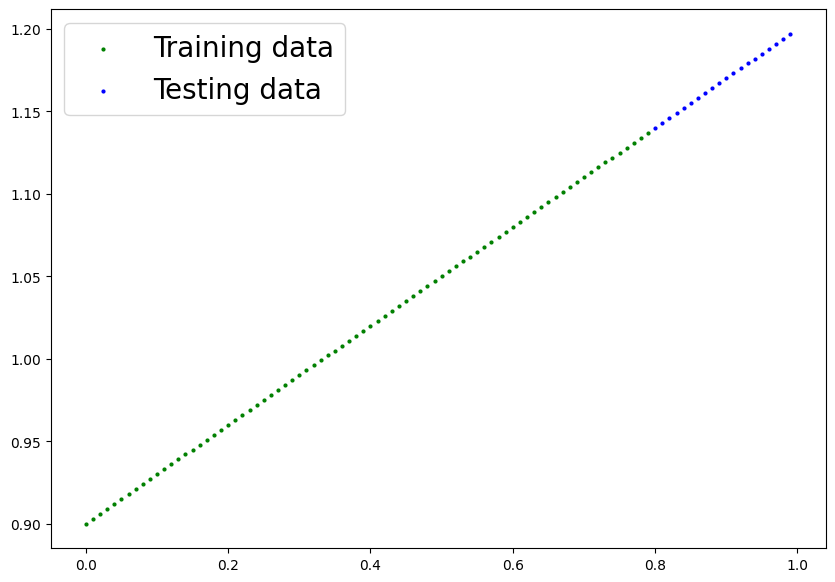

In [86]:
def plot_predictions(train_data=X_train,
                     train_labels=Y_train,
                     test_data=X_test,
                     test_labels=Y_test,
                     predictions=None):
    
    plt.figure(figsize=(10,7))
    plt.scatter(train_data, train_labels, c="g", s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="b", s=4, label="Testing data")
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    plt.legend(prop={"size":20})

plot_predictions()

(Date - 20/Apr/2026)

2. Build a PyTorch model by subclassing nn.Module.

* Inside should be a randomly initialized nn.Parameter() with requires_grad=True, one for weights and one for bias.
* Implement the forward() method to compute the linear regression function you used to create the dataset in 1.
* Once you've constructed the model, make an instance of it and check its state_dict().
* Note: If you'd like to use nn.Linear() instead of nn.Parameter() you can.

In [87]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)
        
    def forward(self, x : torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

In [88]:
torch.manual_seed(7)
model = MyModel()
model, model.state_dict()

(MyModel(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.0698]])),
              ('linear_layer.bias', tensor([-0.6024]))]))

3. Create a loss function and optimizer using nn.L1Loss() and torch.optim.SGD(params, lr) respectively.
* Set the learning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2.
* Write a training loop to perform the appropriate training steps for 300 epochs.
* The training loop should test the model on the test dataset every 20 epochs.

In [89]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model.parameters(),
                            lr = 0.01)

In [90]:
epochs = 300

for epoch in range(epochs):
    model.eval()

    Y_pred = model(X_train)
    train_loss = loss_fn(Y_pred, Y_train)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, X_test)
        print(test_loss.detach().clone().item())

1.42134690284729
1.1506422758102417
0.8799373507499695
0.6092323064804077
0.33852729201316833
0.06782244145870209
0.20288237929344177
0.38511598110198975
0.39506739377975464
0.3808107376098633
0.36551547050476074
0.3502197563648224
0.33423614501953125
0.3179086148738861
0.30192500352859497


4. Make predictions with the trained model on the test data.
* Visualize these predictions against the original training and testing data (note: you may need to make sure the predictions are not on the GPU if you want to use non-CUDA-enabled libraries such as matplotlib to plot).

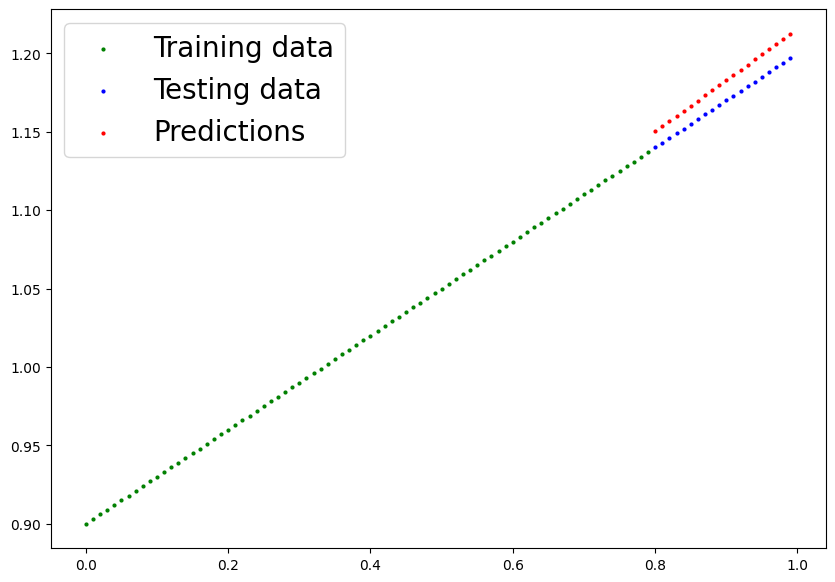

In [91]:
model.eval()
with torch.inference_mode():
    Y_pred = model(X_test)

plot_predictions(predictions=Y_pred.detach())

5. Save your trained model's state_dict() to file.
* Create a new instance of your model class you made in 2. and load in the state_dict() you just saved to it.
* Perform predictions on your test data with the loaded model and confirm they match the original model predictions from 4.

In [92]:
torch.save(obj=model.state_dict(),
           f="models/model_ipynb_22")

In [93]:
loaded_model = MyModel()
raw_data = torch.load(f="models/model_ipynb_22")
loaded_model.load_state_dict(raw_data)

<All keys matched successfully>

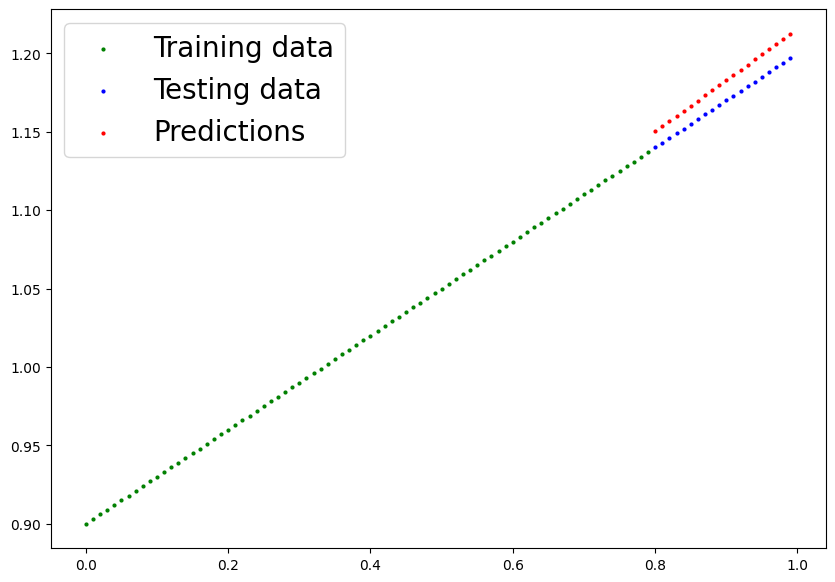

In [94]:
loaded_model.eval()
with torch.inference_mode():
    loaded_pred = loaded_model(X_test)
plot_predictions(predictions=loaded_pred)

### Summary
Date - 20/Apr/2026

I have nothing to write... We have done the exercises and... ya! That's it.